# Easy Run EDA Notebook

This notebook performs exploratory data analysis for easy-run performance metrics.

Primary goals:
- Understand trends in aerobic efficiency and durability.
- Inspect data quality and missingness.
- Explore metric relationships and outliers.
- Build a lightweight baseline model for score prediction.

## 0. Prerequisites Before Running

Ensure the following before executing this notebook:

1. Python 3.13+ and `uv` are installed.
2. Project dependencies are synced (including notebook/dev dependencies):

```powershell
uv sync --dev
```

3. Easy-run analysis CSV is generated (the notebook reads one of these):

- `../reports/hr_improvement_analysis.csv`
- `../reports/easy/hr_improvement_analysis.csv`

Generate/update the CSV with:

```powershell
uv run python main.py easy-score
```

4. In VS Code, select the project kernel (`theeagle` / `.venv`) and then run all cells top-to-bottom.

If a CSV file-not-found error appears, rerun `uv run python main.py easy-score` and execute the notebook again.

## 1. Environment Setup and Imports

Import core data science libraries and configure plotting/display options.

In [29]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Libraries loaded. scikit-learn available:", SKLEARN_AVAILABLE)

Libraries loaded. scikit-learn available: True


## 2. Notebook Parameters and File Paths

Define configurable parameters, input/output paths, and reusable constants.

In [30]:
# Paths
REPORT_CSV = Path("../reports/hr_improvement_analysis.csv")
FALLBACK_CSV = Path("../reports/easy/hr_improvement_analysis.csv")
OUTPUT_DIR = Path("../reports/easy")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility and analysis constants
RANDOM_SEED = 42
TEST_SIZE = 0.25
ROLLING_WINDOW = 3
EF_TRAINED_THRESHOLD = 1.8
DECOUPLING_FIT_THRESHOLD = 5.0

KEY_METRICS = [
    "steady_power_per_hr",
    "aerobic_drift_pct",
    "fatigue_resilience_score",
    "steady_pace_min_per_km",
    "easy_run_score",
]

print("Primary CSV:", REPORT_CSV)
print("Fallback CSV:", FALLBACK_CSV)
print("Output dir:", OUTPUT_DIR.resolve())

Primary CSV: ..\reports\hr_improvement_analysis.csv
Fallback CSV: ..\reports\easy\hr_improvement_analysis.csv
Output dir: C:\Users\A717631\repo\theEagle\reports\easy


## 3. Load Dataset

Read the analysis dataset, parse date, and inspect high-level structure.

In [31]:
data_path = REPORT_CSV if REPORT_CSV.exists() else FALLBACK_CSV

if not data_path.exists():
    raise FileNotFoundError(
        "No HR analysis CSV found. Run: python src/hr_improvement_tracker.py"
    )

df = pd.read_csv(data_path)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date")

print("Loaded:", data_path)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head(5)

Loaded: ..\reports\hr_improvement_analysis.csv
Shape: (9, 124)
Columns:
['file', 'date', 'filename_date', 'filename_mismatch', 'workout_title', 'avg_hr', 'max_hr', 'min_hr', 'std_hr', 'hr_readings', 'avg_power', 'normalized_power', 'max_power', 'avg_speed_mps', 'moving_speed_mps', 'best_speed_mps', 'pace_min_per_km', 'moving_pace_min_per_km', 'best_pace_min_per_km', 'duration_min', 'distance_km', 'total_ascent_m', 'total_descent_m', 'avg_temperature_c', 'max_temperature_c', 'power_per_hr', 'speed_per_hr', 'aerobic_drift_pct', 'power_hr_decoupling_pct', 'pace_durability_pct', 'recovery_hr_60s_bpm', 'power_stability_cv_pct', 'cadence_stability_cv_pct', 'avg_running_cadence', 'max_running_cadence', 'avg_stride_length_m', 'avg_stance_time_ms', 'avg_vertical_oscillation_mm', 'avg_vertical_ratio_pct', 'left_right_balance_pct', 'aerobic_training_effect', 'anaerobic_training_effect', 'exercise_load', 'measured_load_focus_category', 'estimated_load_focus_category', 'vo2max', 'body_battery_befor

,file,date,filename_date,filename_mismatch,workout_title,avg_hr,max_hr,min_hr,std_hr,hr_readings,avg_power,normalized_power,max_power,avg_speed_mps,moving_speed_mps,best_speed_mps,pace_min_per_km,moving_pace_min_per_km,best_pace_min_per_km,duration_min,distance_km,total_ascent_m,total_descent_m,avg_temperature_c,max_temperature_c,power_per_hr,speed_per_hr,aerobic_drift_pct,power_hr_decoupling_pct,pace_durability_pct,recovery_hr_60s_bpm,power_stability_cv_pct,cadence_stability_cv_pct,avg_running_cadence,max_running_cadence,avg_stride_length_m,avg_stance_time_ms,avg_vertical_oscillation_mm,avg_vertical_ratio_pct,left_right_balance_pct,aerobic_training_effect,anaerobic_training_effect,exercise_load,measured_load_focus_category,estimated_load_focus_category,vo2max,body_battery_before_run,hrv_status,stress_level,recovery_time_recommendation_h,sleep_time_profile,wake_time_profile,resting_heart_rate,weight_kg,avg_power_wkg,max_power_wkg,functional_threshold_power,threshold_heart_rate,max_heart_rate_setting,hr_zone_source,power_zone_source,running_economy_w_per_mps,energy_cost_j_per_m,total_work_kj,fatigue_resilience_score,hr_z1_sec,hr_z1_pct,hr_z2_sec,hr_z2_pct,hr_z3_sec,hr_z3_pct,hr_z4_sec,hr_z4_pct,hr_z5_sec,hr_z5_pct,power_z1_sec,power_z1_pct,power_z2_sec,power_z2_pct,power_z3_sec,power_z3_pct,power_z4_sec,power_z4_pct,power_z5_sec,power_z5_pct,zone2_duration_min,zone2_avg_hr,zone2_pace_min_per_km,zone2_avg_power,steady_start_km,steady_end_km,steady_avg_hr,steady_avg_speed_mps,steady_pace_min_per_km,steady_avg_power,steady_speed_per_hr,steady_power_per_hr,steady_hr_rise_bpm,steady_hr_std,week,day_name,date_str,pace_str,steady_pace_str,duration_bucket,ef_score,decoupling_score,stability_score,easy_run_score,score_label,timeline_status,timeline_note,reference_date,pace_change_vs_reference_pct,steady_hr_change_vs_reference_pct,ef_change_vs_reference_pct,drift_delta_vs_reference_pct_pts,hr_cost_change_vs_reference_pct,pace_change_at_similar_hr_pct,hr_change_at_similar_pace_pct,rolling_3run_duration_min,rolling_3run_total_work_kj,rolling_3run_training_effect,temperature_vs_median_c
0,2026-04-16_thursday_easy.fit,2026-04-16 05:27:56,2026-04-16,False,45Min Easy,148.0,158,73,9.4,2703,230.0,231.0,273.0,2.230,2.233,2.613,7.47,7.46,6.38,45.0,6.03,4.0,2.0,NaN,NaN,1.554,0.01507,7.21,5.20,1.06,NaN,7.27,6.11,83.0,90.0,0.797,280.8,78.6,9.88,NaN,3.0,0.0,NaN,NaN,low_aerobic_estimated,NaN,NaN,NaN,NaN,NaN,21:30:00,04:30:00,74.0,72.0,3.19,3.79,338.0,176.0,198.0,garmin_percent_max_hr,garmin_percent_ftp,103.1,103.1,621.3,41.7,44,1.6,229,8.5,2430,89.9,0,0.0,0,0.0,17,0.6,2638,97.8,41,1.5,0,0.0,0,0.0,3.8,134.7,7.46,225.2,2.00,5.72,151.4,2.230,7.47,232.5,0.01473,1.536,6.0,3.6,15,Thursday,2026-04-16,7.47,7.47,standard_easy,57.8,42.3,79.0,55.6,good,baseline,First run. EF 1.536 W/bpm (Joe Friel scale: 0....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.0,621.3,3.0,NaN
1,2026-04-18_saturday_easy.fit,2026-04-18 05:53:31,2026-04-18,False,7k Easy,155.0,167,107,7.3,3169,228.0,232.0,324.0,2.212,2.244,2.930,7.53,7.43,5.69,52.8,7.01,4.0,4.0,31.0,32.0,1.471,0.01427,2.51,1.31,-3.01,NaN,10.22,7.52,81.0,89.0,0.809,281.4,79.4,9.85,NaN,3.1,0.0,NaN,NaN,low_aerobic_estimated,NaN,NaN,NaN,NaN,NaN,21:30:00,04:30:00,73.0,72.0,3.17,4.50,302.0,176.0,198.0,garmin_percent_max_hr,garmin_percent_ftp,103.1,103.1,721.4,99.4,19,0.6,134,4.2,1933,61.0,1083,34.2,0,0.0,51,1.6,769,24.7,2293,73.6,3,0.1,1,0.0,1.6,131.9,8.29,207.5,2.00,6.66,157.9,2.245,7.42,232.6,0.01422,1.474,4.1,3.9,15,Saturday,2026-04-18,7.53,7.42,standard_easy,52.2,79.9,76.0,65.5,good,improving,EF dropped -4.0% to 1.474 W/bpm; aerobic decou...,2026-04-16,0.7,-4.1,-4.0,-4.7,-3.5,NaN,-4.1,97.8,1342.7,6.1,0.5
2,2026-04-23_thursday_easy.fit,2026-04-23 05:32:50,2026-04-23,False,45min Easy,149.0,157,73,8.0,2703,236.0,237.0,271.0,2.274,2.269,2.519,7.33,7.35,6.62,45.0,6.14,3.0,3.0,30.0,31.0,1.584,0.01526,4.95,3.43,0.57,NaN,5.66,4.15,82.0,88.0,0.821,284.2,81.0,9.87,NaN,3.0,0.0,NaN,NaN,low_aerobic_estimated,NaN,NaN,NaN,NaN,NaN,21:30:00,04:30:00,6

## 4. Data Cleaning and Feature Preparation

Check data quality and prepare numeric features for analysis and modeling.

In [32]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missing columns (%):")
print(missing_pct.head(20).round(2))

print("\nDuplicate rows:", int(df.duplicated().sum()))
print("\nDtypes:")
print(df.dtypes.sort_index())

numeric_df = df.select_dtypes(include=[np.number]).copy()
print("\nNumeric summary:")
display(numeric_df.describe().T)

# Minimal preprocessing for model cell
model_df = numeric_df.copy()
if "easy_run_score" in model_df.columns:
    model_df = model_df.dropna(subset=["easy_run_score"])
model_df = model_df.fillna(model_df.median(numeric_only=True))

feature_cols = [c for c in model_df.columns if c != "easy_run_score"]
X = model_df[feature_cols] if feature_cols else pd.DataFrame()
y = model_df["easy_run_score"] if "easy_run_score" in model_df.columns else pd.Series(dtype=float)

print("Model-ready shape:", model_df.shape)
print("Feature count:", len(feature_cols))

Top missing columns (%):
left_right_balance_pct               100.00
measured_load_focus_category         100.00
exercise_load                        100.00
recovery_time_recommendation_h       100.00
vo2max                               100.00
body_battery_before_run              100.00
hrv_status                           100.00
stress_level                         100.00
recovery_hr_60s_bpm                  100.00
pace_change_at_similar_hr_pct         44.44
avg_temperature_c                     11.11
filename_date                         11.11
steady_hr_change_vs_reference_pct     11.11
reference_date                        11.11
hr_cost_change_vs_reference_pct       11.11
drift_delta_vs_reference_pct_pts      11.11
ef_change_vs_reference_pct            11.11
pace_change_vs_reference_pct          11.11
hr_change_at_similar_pace_pct         11.11
temperature_vs_median_c               11.11
dtype: float64

Duplicate rows: 0

Dtypes:
aerobic_drift_pct            float64
aerobic_trainin

,count,mean,std,min,25%,50%,75%,max
avg_hr,9.0,150.222222,2.438123,147.0,149.0,150.0,152.000,155.0
max_hr,9.0,161.888889,3.333333,157.0,160.0,161.0,164.000,167.0
min_hr,9.0,81.222222,13.207742,67.0,73.0,75.0,87.000,107.0
std_hr,9.0,9.155556,1.253107,7.3,8.2,9.4,10.000,11.1
hr_readings,9.0,3489.777778,858.828530,2207.0,2703.0,3608.0,4400.000,4506.0
...,...,...,...,...,...,...,...,...
hr_change_at_similar_pace_pct,8.0,-0.137500,2.551715,-4.1,-2.0,0.3,1.325,3.9
rolling_3run_duration_min,9.0,149.377778,54.124689,45.0,134.6,142.8,193.500,210.2
rolling_3run_total_work_kj,9.0,2092.888889,763.231964,621.3,1877.7,2024.1,2744.200,2919.4
rolling_3run_training_effect,9.0,8.188889,2.213845,3.0,8.9,9.1,9.400,9.5


Model-ready shape: (9, 107)
Feature count: 106


## 5. Exploratory Visualizations

Explore distributions, trends, correlations, and zone behavior.

Interpretation guide:
- Lower aerobic_drift_pct is usually better aerobic durability.
- Higher steady_power_per_hr indicates better efficiency at a given HR.
- Lower steady_pace_min_per_km means faster pace.

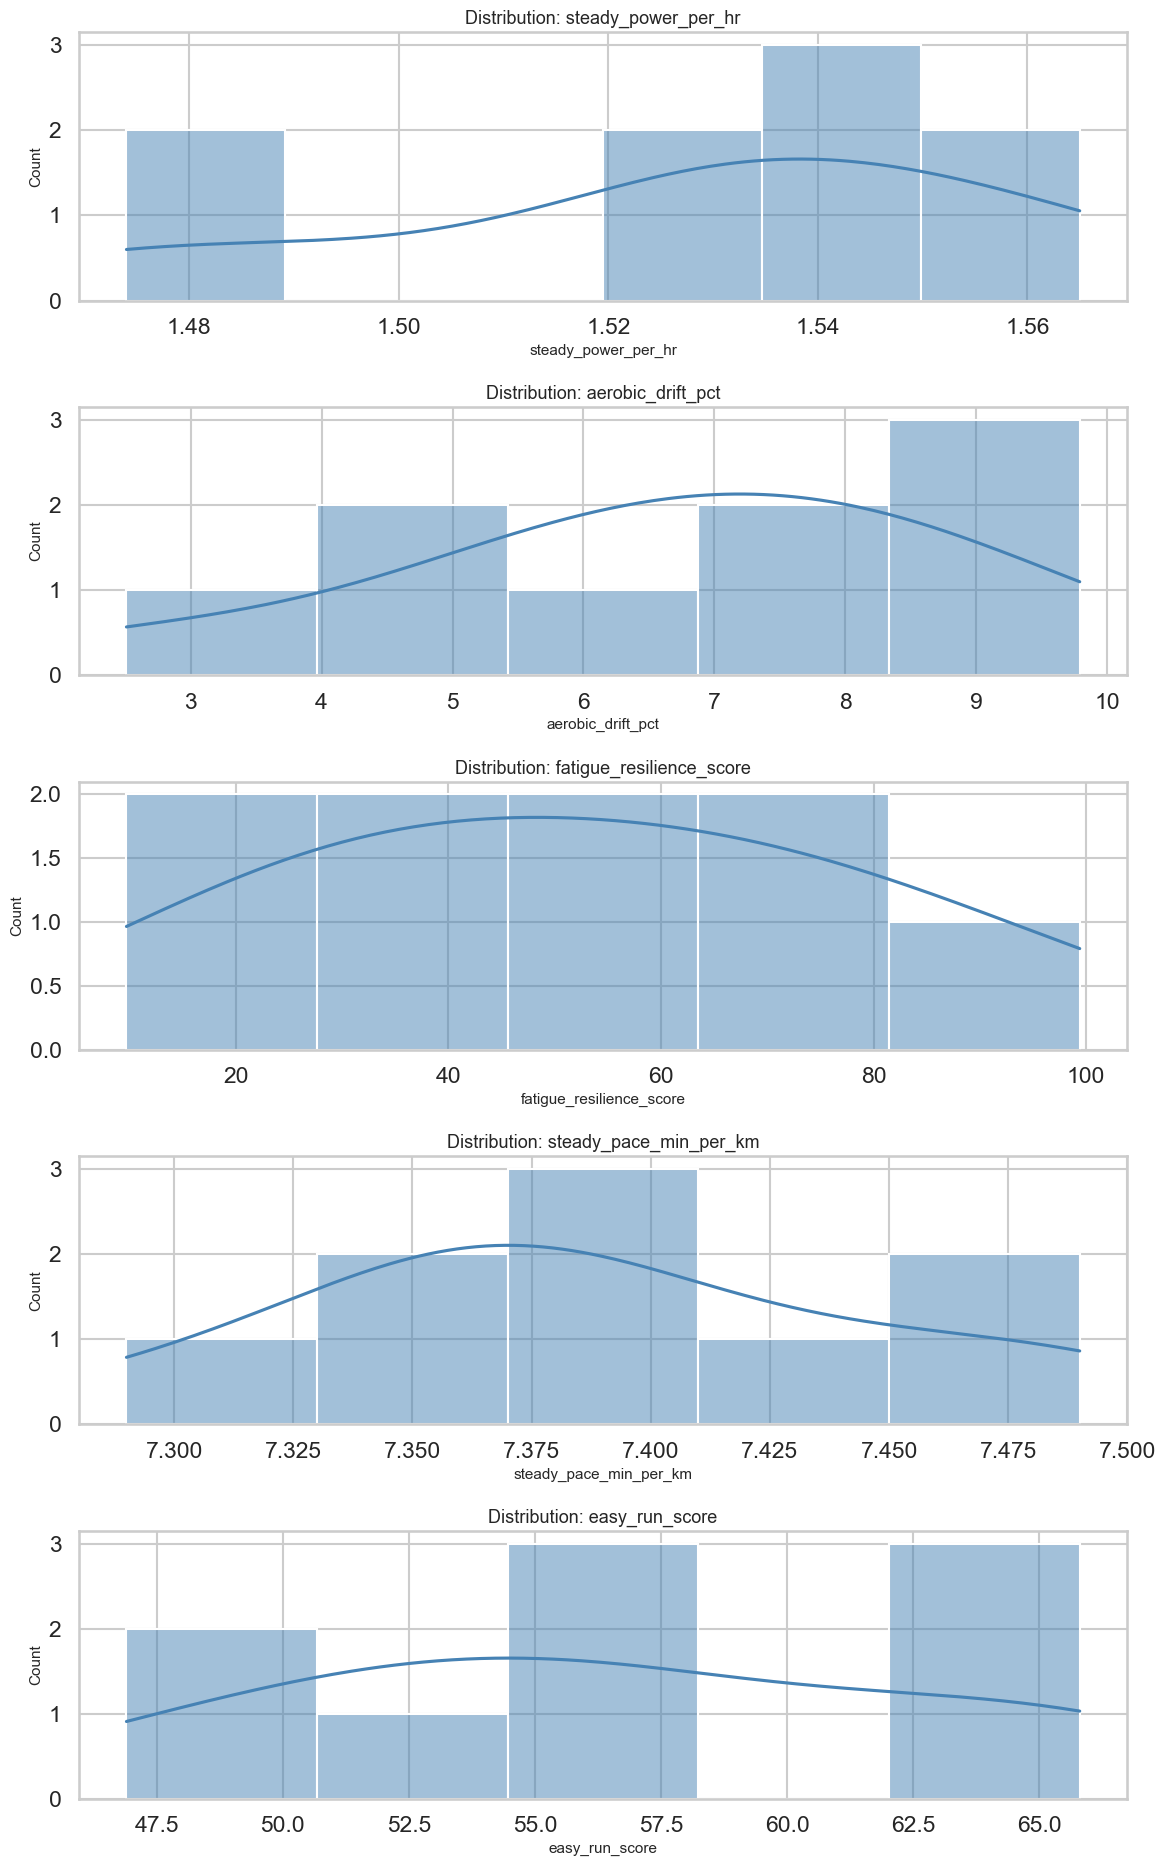

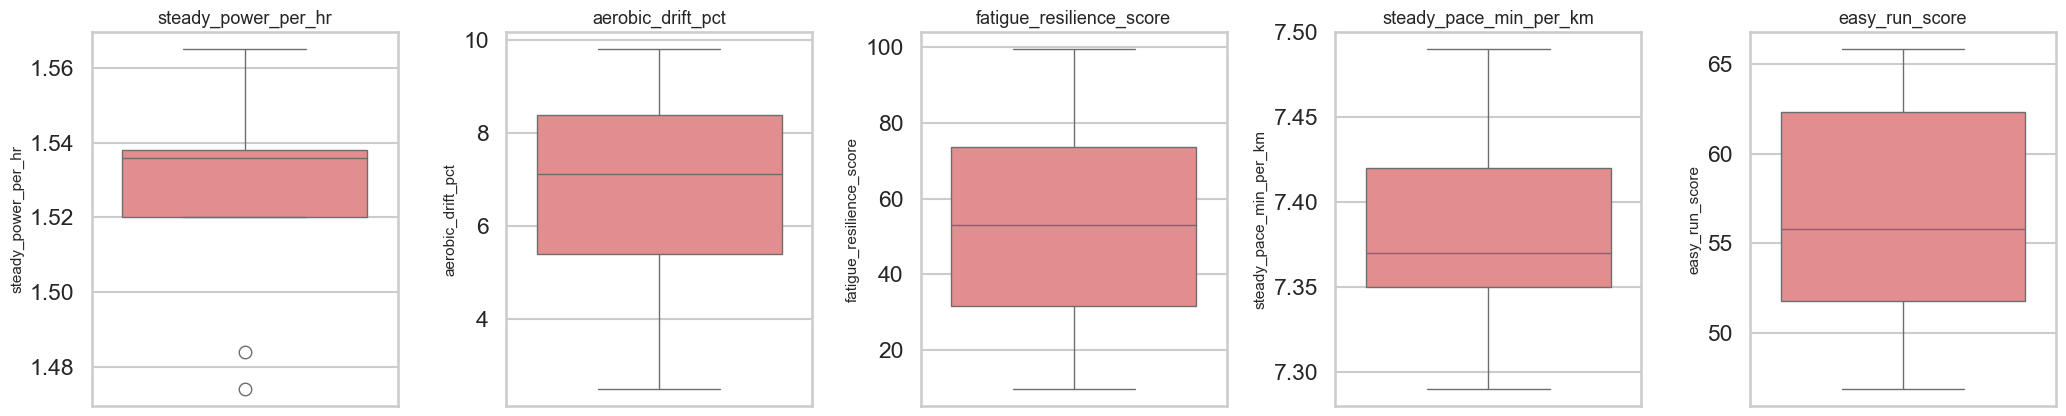

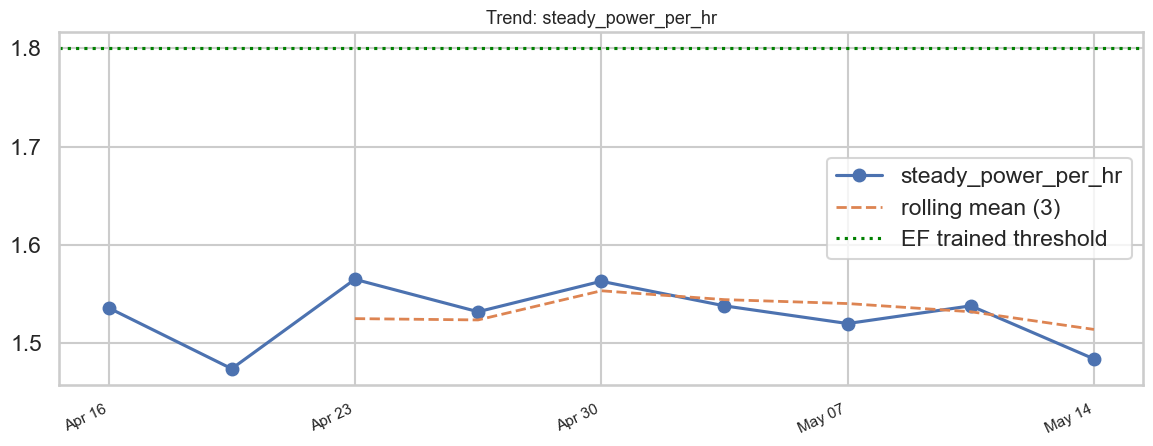

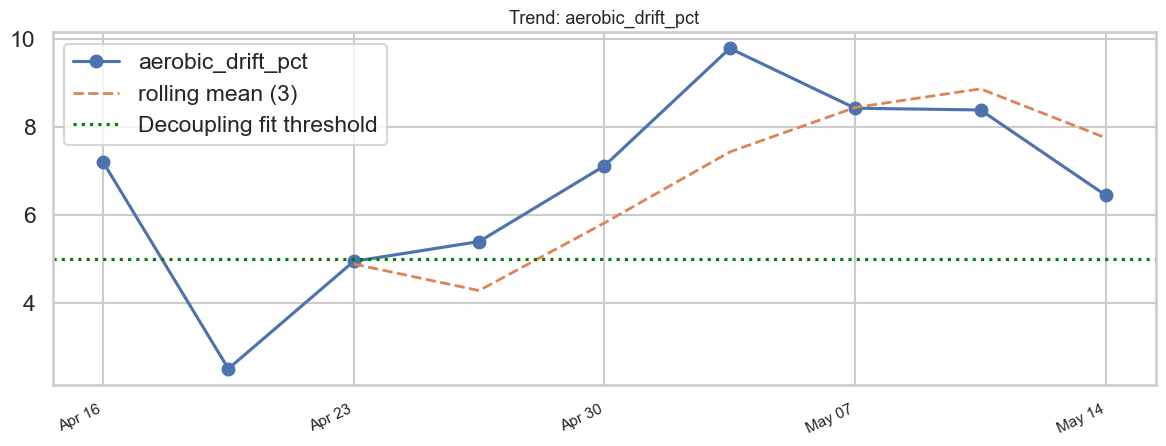

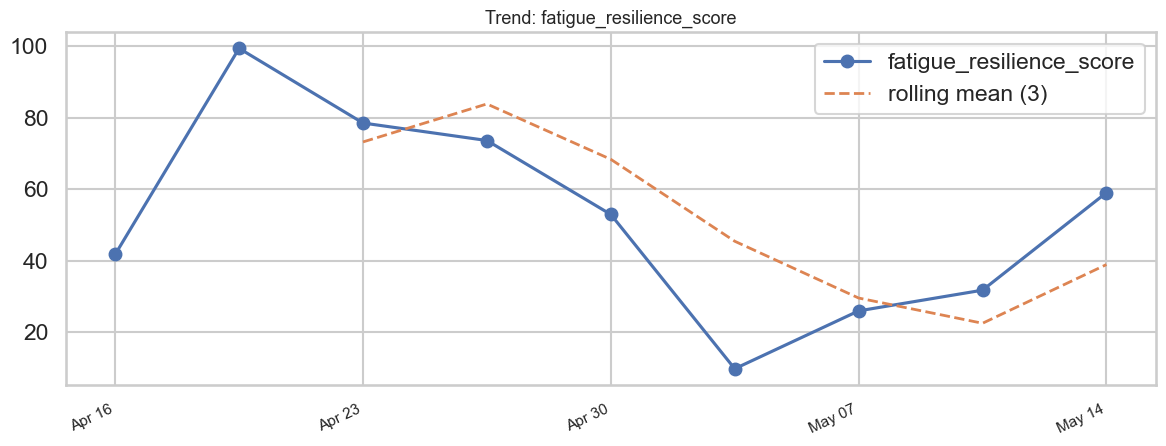

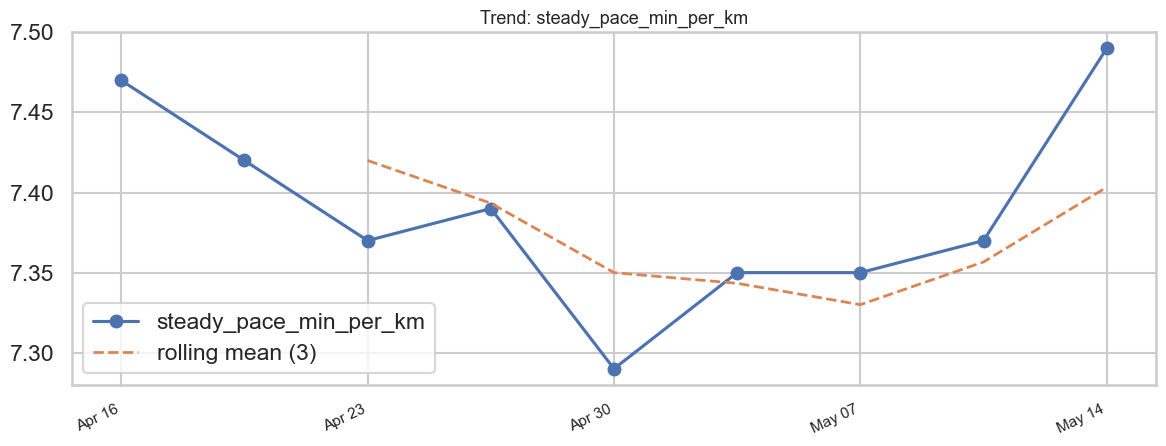

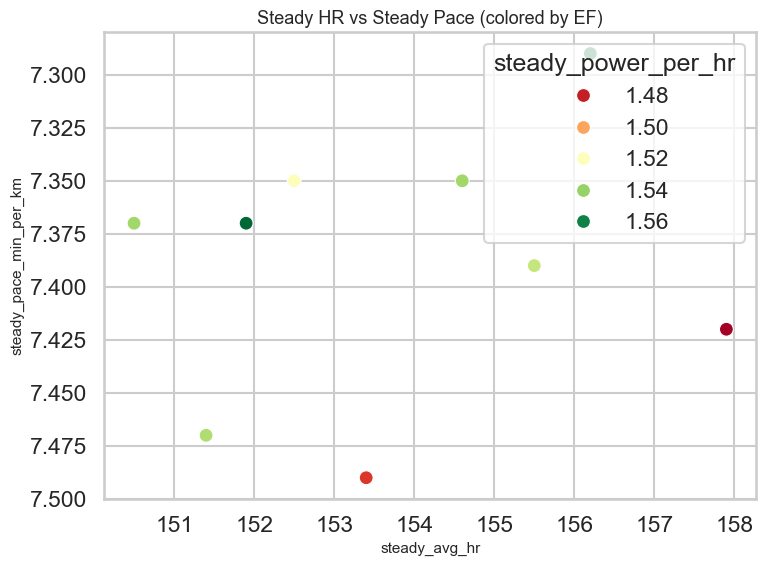

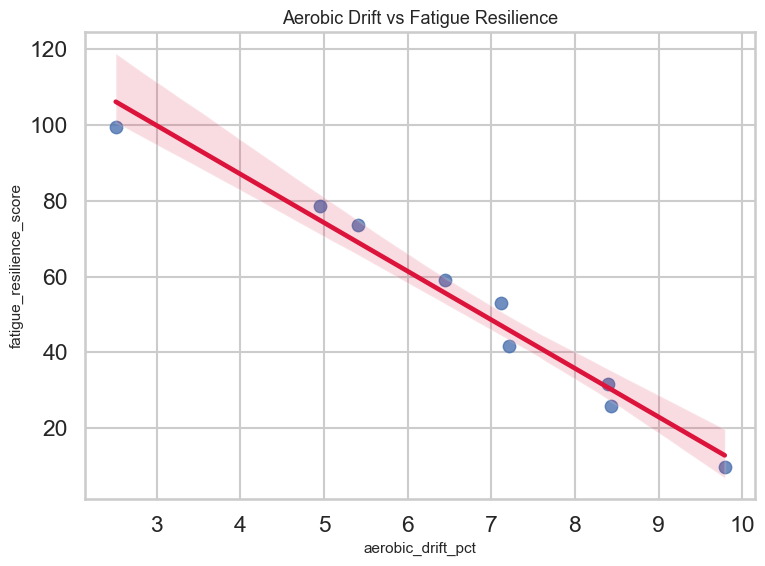

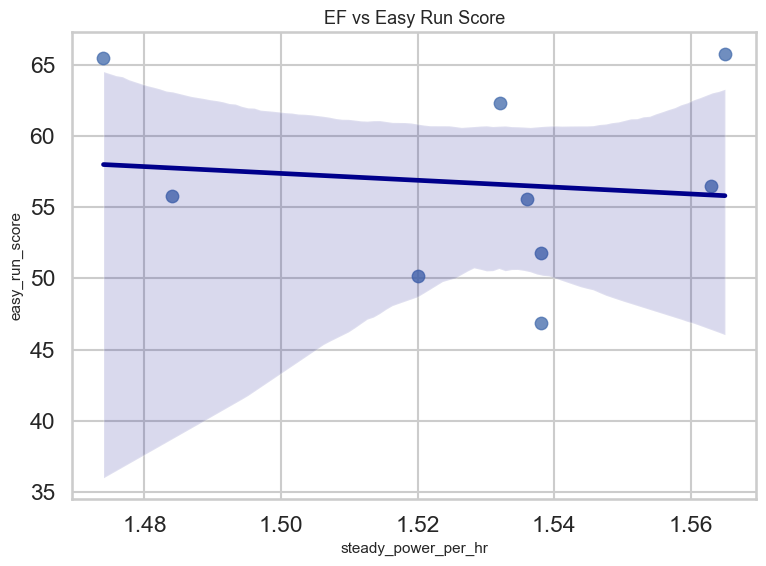

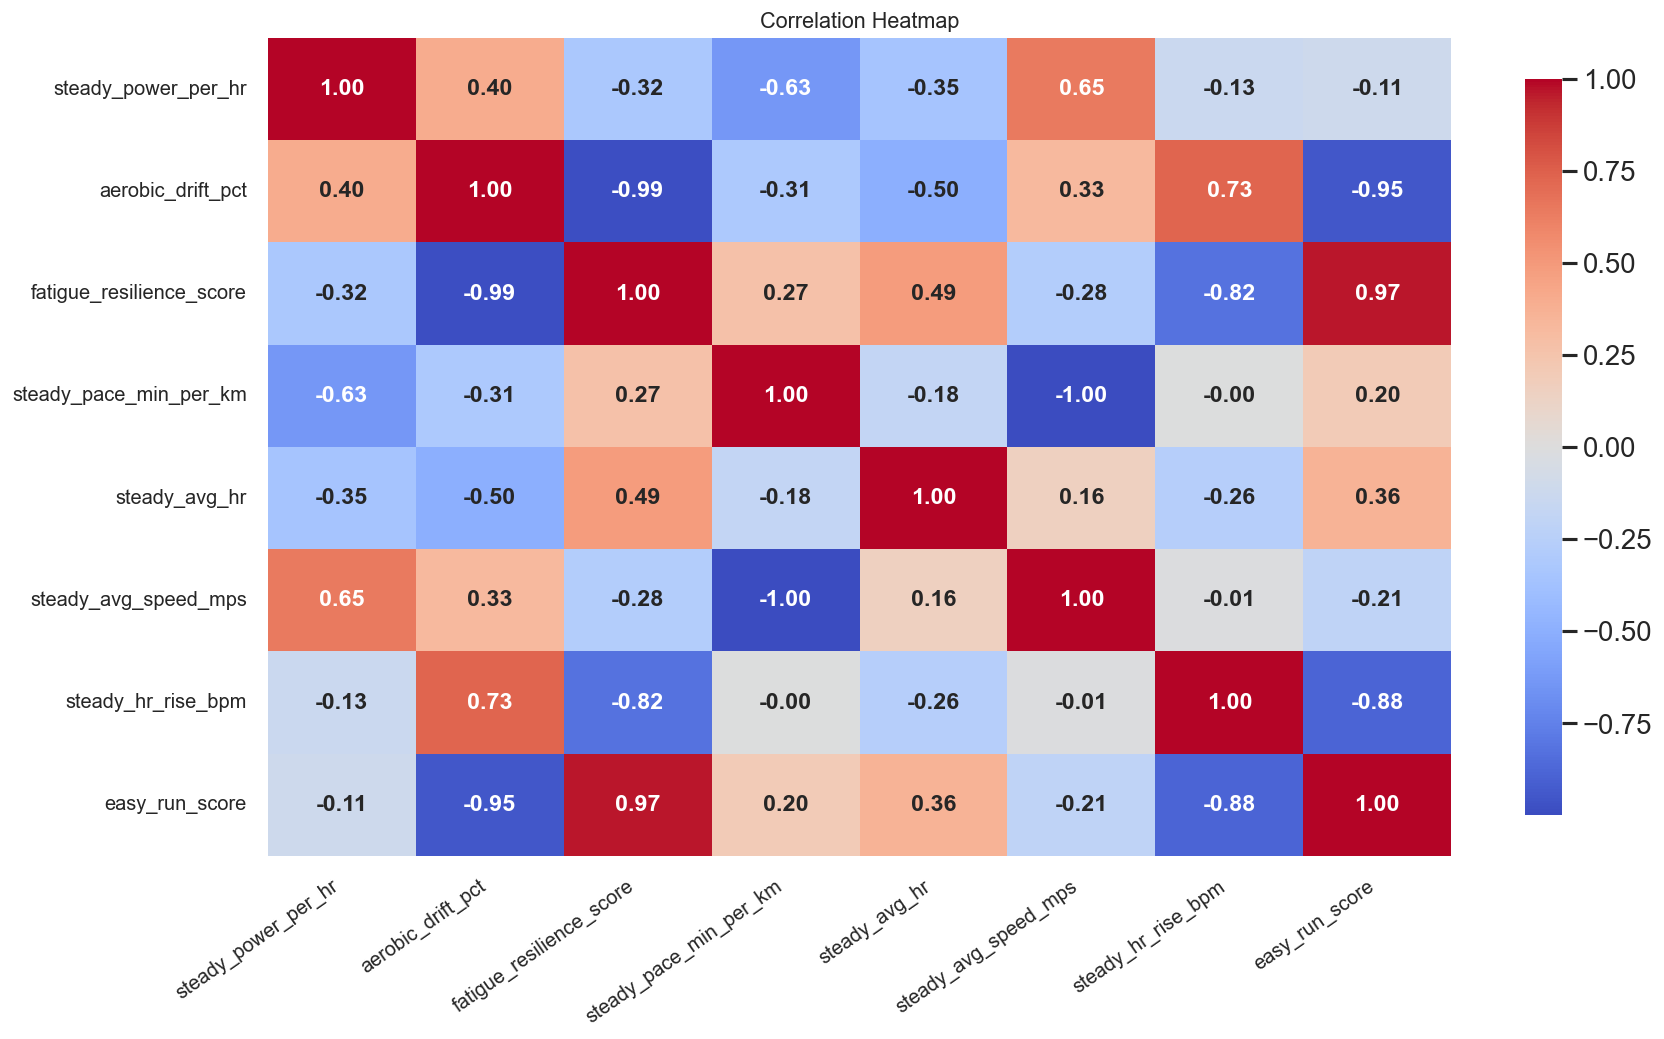

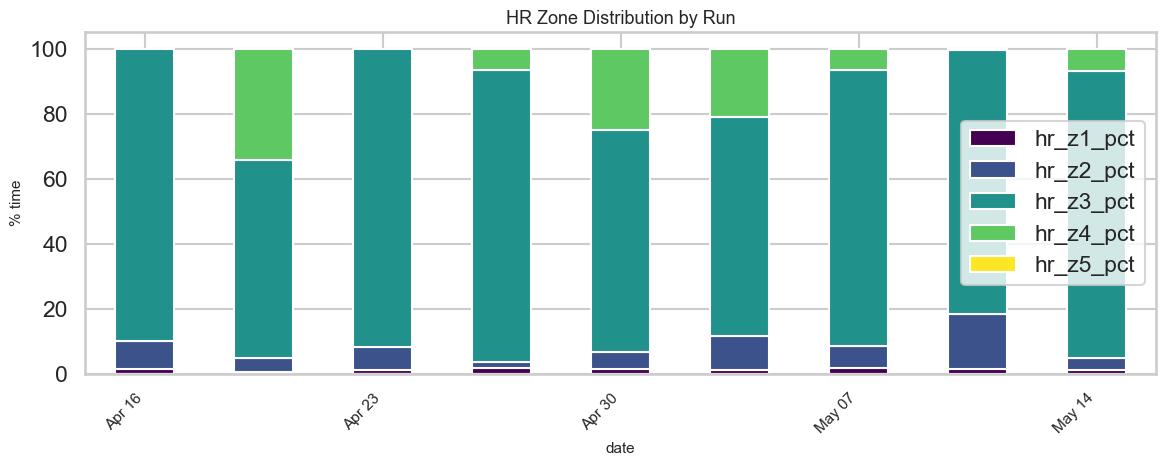

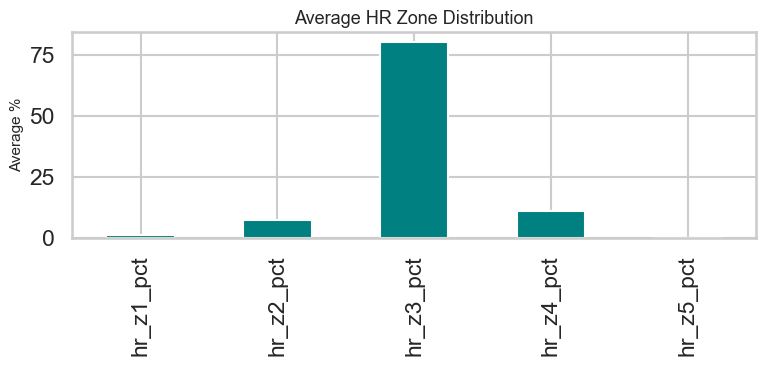

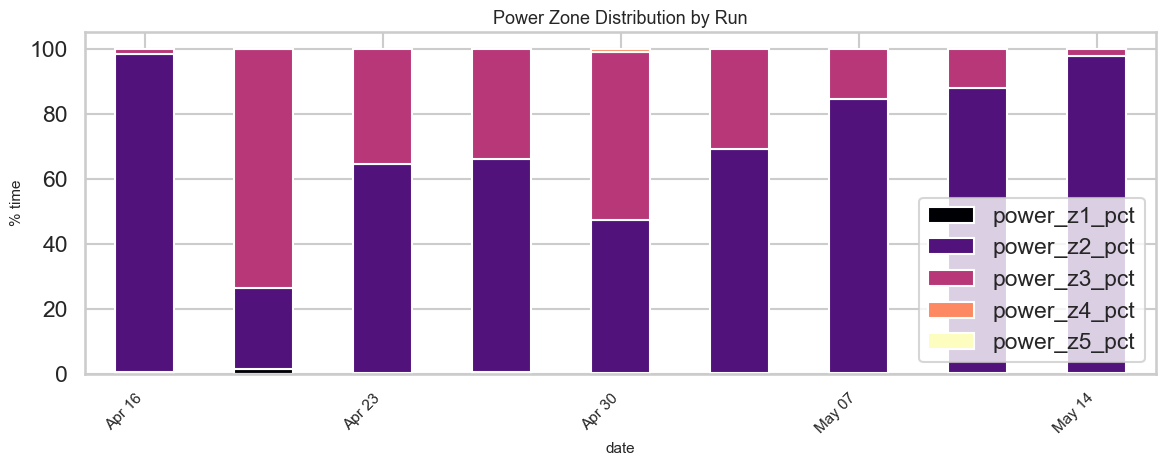

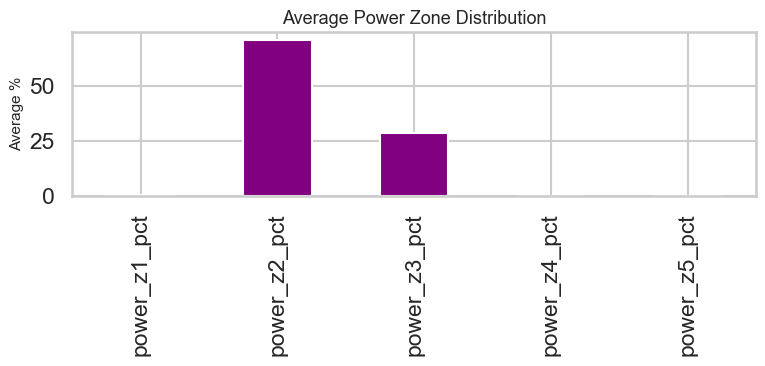

,week,steady_power_per_hr,aerobic_drift_pct,steady_pace_min_per_km
0,2026-04-13,1.5050,4.860,7.445
1,2026-04-20,1.5485,5.175,7.380
2,2026-04-27,1.5505,8.455,7.320
3,2026-05-04,1.5290,8.410,7.360
4,2026-05-11,1.4840,6.450,7.490


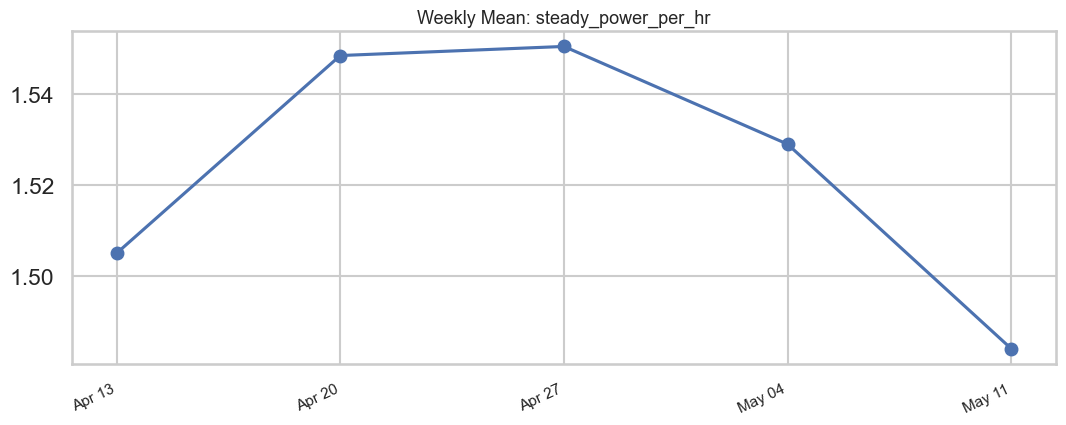

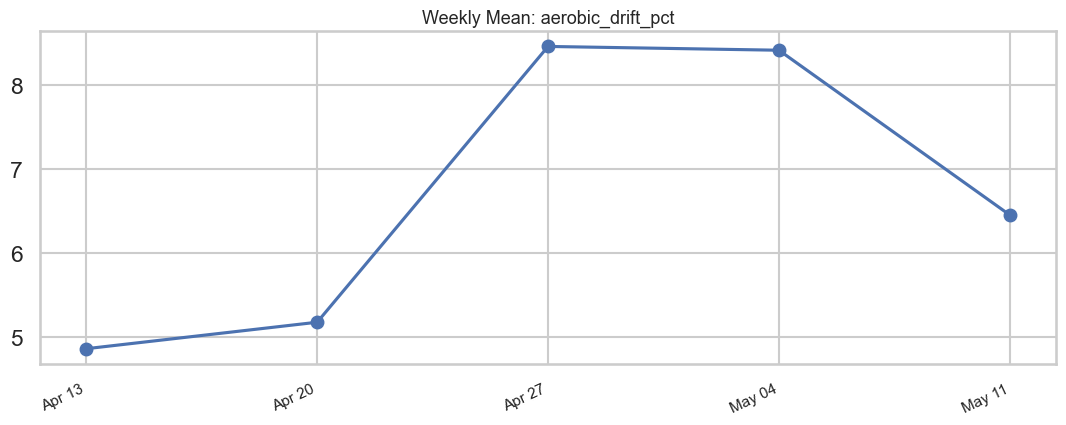

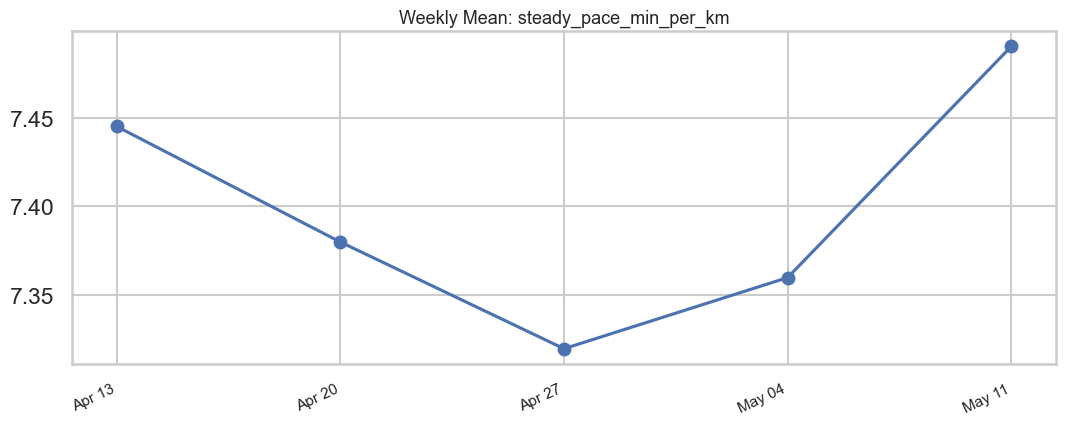

Flagged runs count: 5


,date,aerobic_drift_pct,steady_power_per_hr,fatigue_resilience_score,easy_run_score
1,2026-04-18 05:53:31,2.51,1.474,99.4,65.5
5,2026-05-02 05:25:54,9.79,1.538,9.7,46.9
6,2026-05-07 05:37:49,8.43,1.520,25.9,50.2
7,2026-05-09 06:07:28,8.39,1.538,31.7,51.8
8,2026-05-14 05:26:26,6.45,1.484,59.0,55.8


In [33]:
available_metrics = [c for c in KEY_METRICS if c in df.columns]
if available_metrics:
    # Histograms + KDE
    n = len(available_metrics)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.8 * n))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, available_metrics):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
        ax.set_title(f"Distribution: {col}")
    plt.tight_layout()
    plt.show()

    # Boxplots
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, available_metrics):
        sns.boxplot(y=df[col], ax=ax, color="lightcoral")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()
else:
    print("No key metrics found for distribution plots.")

# READABILITY_PATCH_V3
def _set_sparse_date_ticks(ax, labels, max_ticks=6, rotation=25, fontsize=11):
    labels = list(labels)
    n = len(labels)
    if n == 0:
        return
    step = max(1, int(np.ceil(n / max_ticks)))
    idx = np.arange(0, n, step)
    ax.set_xticks(idx)
    ax.set_xticklabels([labels[i] for i in idx], rotation=rotation, ha="right", fontsize=fontsize)

# Time trends
if "date" in df.columns and df["date"].notna().any() and available_metrics:
    trend_cols = [c for c in ["steady_power_per_hr", "aerobic_drift_pct", "fatigue_resilience_score", "steady_pace_min_per_km"] if c in df.columns]
    for col in trend_cols:
        plot_df = df[["date", col]].dropna().sort_values("date")
        if plot_df.empty:
            continue
        x = np.arange(len(plot_df))
        labels = plot_df["date"].dt.strftime("%b %d")
        plt.figure(figsize=(12, 4.8))
        plt.plot(x, plot_df[col], marker="o", label=col)
        if len(plot_df) >= ROLLING_WINDOW:
            roll = plot_df[col].rolling(ROLLING_WINDOW).mean()
            plt.plot(x, roll, linestyle="--", linewidth=2, label=f"rolling mean ({ROLLING_WINDOW})")
        if col == "steady_power_per_hr":
            plt.axhline(EF_TRAINED_THRESHOLD, linestyle=":", color="green", label="EF trained threshold")
        if col == "aerobic_drift_pct":
            plt.axhline(DECOUPLING_FIT_THRESHOLD, linestyle=":", color="green", label="Decoupling fit threshold")
        plt.title(f"Trend: {col}")
        plt.legend()
        _set_sparse_date_ticks(plt.gca(), labels, max_ticks=6, rotation=25, fontsize=11)
        plt.tight_layout()
        plt.show()
else:
    print("Skipping trend plots (date or key metrics unavailable).")

# Relationship plots
if {"steady_avg_hr", "steady_pace_min_per_km", "steady_power_per_hr"}.issubset(df.columns):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="steady_avg_hr", y="steady_pace_min_per_km", hue="steady_power_per_hr", palette="RdYlGn", s=100)
    plt.gca().invert_yaxis()
    plt.title("Steady HR vs Steady Pace (colored by EF)")
    plt.tight_layout()
    plt.show()

if {"aerobic_drift_pct", "fatigue_resilience_score"}.issubset(df.columns):
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x="aerobic_drift_pct", y="fatigue_resilience_score", scatter_kws={"s": 80}, line_kws={"color": "crimson"})
    plt.title("Aerobic Drift vs Fatigue Resilience")
    plt.tight_layout()
    plt.show()

if {"steady_power_per_hr", "easy_run_score"}.issubset(df.columns):
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df, x="steady_power_per_hr", y="easy_run_score", scatter_kws={"s": 80}, line_kws={"color": "darkblue"})
    plt.title("EF vs Easy Run Score")
    plt.tight_layout()
    plt.show()

# Correlation heatmap
corr_cols = [c for c in [
    "steady_power_per_hr", "aerobic_drift_pct", "fatigue_resilience_score", "steady_pace_min_per_km",
    "steady_avg_hr", "steady_avg_speed_mps", "steady_hr_rise_bpm", "easy_run_score"
] if c in numeric_df.columns]

if len(corr_cols) >= 2:
    plt.figure(figsize=(15, 9), dpi=120)
    corr = numeric_df[corr_cols].corr()
    ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=False, annot_kws={"size": 14, "weight": "bold"}, cbar_kws={"shrink": 0.9})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough columns for correlation heatmap.")

# Zone behavior
hr_zone_cols = [c for c in ["hr_z1_pct", "hr_z2_pct", "hr_z3_pct", "hr_z4_pct", "hr_z5_pct"] if c in df.columns]
power_zone_cols = [c for c in ["power_z1_pct", "power_z2_pct", "power_z3_pct", "power_z4_pct", "power_z5_pct"] if c in df.columns]

if "date" in df.columns and hr_zone_cols:
    z = df[["date"] + hr_zone_cols].dropna().sort_values("date")
    if not z.empty:
        z_plot = z.set_index("date")
        z_plot.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="viridis")
        plt.title("HR Zone Distribution by Run")
        plt.ylabel("% time")
        labels = pd.to_datetime(z_plot.index).strftime("%b %d")
        _set_sparse_date_ticks(plt.gca(), labels, max_ticks=6, rotation=45, fontsize=11)
        plt.tight_layout()
        plt.show()

        z_plot.mean().plot(kind="bar", figsize=(8, 4), color="teal")
        plt.title("Average HR Zone Distribution")
        plt.ylabel("Average %")
        plt.tight_layout()
        plt.show()

if "date" in df.columns and power_zone_cols:
    z = df[["date"] + power_zone_cols].dropna().sort_values("date")
    if not z.empty:
        z_plot = z.set_index("date")
        z_plot.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="magma")
        plt.title("Power Zone Distribution by Run")
        plt.ylabel("% time")
        labels = pd.to_datetime(z_plot.index).strftime("%b %d")
        _set_sparse_date_ticks(plt.gca(), labels, max_ticks=6, rotation=45, fontsize=11)
        plt.tight_layout()
        plt.show()

        z_plot.mean().plot(kind="bar", figsize=(8, 4), color="purple")
        plt.title("Average Power Zone Distribution")
        plt.ylabel("Average %")
        plt.tight_layout()
        plt.show()

# Weekly aggregation
weekly = pd.DataFrame()
if "date" in df.columns and df["date"].notna().any():
    wdf = df.dropna(subset=["date"]).copy()
    wdf["week"] = wdf["date"].dt.to_period("W").dt.start_time
    weekly_cols = [c for c in ["steady_power_per_hr", "aerobic_drift_pct", "steady_pace_min_per_km"] if c in wdf.columns]
    if weekly_cols:
        weekly = wdf.groupby("week", as_index=False)[weekly_cols].mean()
        display(weekly.tail(10))

        xw = np.arange(len(weekly))
        week_labels = weekly["week"].dt.strftime("%b %d")
        for col in weekly_cols:
            plt.figure(figsize=(11, 4.6))
            plt.plot(xw, weekly[col], marker="o")
            plt.title(f"Weekly Mean: {col}")
            _set_sparse_date_ticks(plt.gca(), week_labels, max_ticks=5, rotation=25, fontsize=11)
            plt.tight_layout()
            plt.show()

# Anomaly flags
flag_cols = ["date", "aerobic_drift_pct", "steady_power_per_hr", "fatigue_resilience_score", "easy_run_score"]
flag_cols = [c for c in flag_cols if c in df.columns]

if {"aerobic_drift_pct", "steady_power_per_hr", "fatigue_resilience_score"}.issubset(df.columns):
    ef_p20 = df["steady_power_per_hr"].quantile(0.20)
    flagged = df[
        (df["aerobic_drift_pct"] > 8)
        | (df["steady_power_per_hr"] < ef_p20)
        | (df["fatigue_resilience_score"] < 30)
    ][flag_cols].sort_values("date" if "date" in flag_cols else flag_cols[0])

    print("Flagged runs count:", len(flagged))
    display(flagged)
else:
    print("Skipping anomaly flags (required columns unavailable).")


## 5.1 How to Read the Charts

### Distribution (Histogram + KDE)
What it shows: Spread of values, common range, and extremes.
How to read: Taller bars mean frequent values; long tails suggest unusual sessions.
Good sign: Most runs cluster in a stable expected range.
Warning sign: Wide spread or sudden shift in center.
What to do: Review outliers with fatigue, sleep, weather, and load context.

### Boxplot
What it shows: Median, typical range (IQR), and outliers.
How to read: Middle line is median, box is typical range, points are outliers.
Good sign: Stable median and box width over time.
Warning sign: Box widens or many low-quality outliers appear.
What to do: Inspect outlier sessions and adjust intensity/recovery.

### Trends (EF, Drift, Fatigue Resilience, Pace)
What it shows: Change across runs.
How to read: EF up is usually good; drift down is good; resilience up is good; pace (min/km) down is faster.
Good sign: EF stable/up, drift stable/down, resilience stable/up, pace stable/improving.
Warning sign: 2+ weeks of EF down + drift up + slower pace.
What to do: Use a recovery/deload week, then rebuild gradually.

### Steady HR vs Steady Pace (colored by EF)
What it shows: Relationship between heart rate, pace, and efficiency.
How to read: Better zone is lower HR + faster pace + stronger EF color.
Good sign: Points move toward better pace at lower HR over time.
Warning sign: Cluster of high HR with slower pace.
What to do: Keep easy days easy and avoid excess fatigue.

### Aerobic Drift vs Fatigue Resilience
What it shows: Whether higher drift is linked to lower resilience.
How to read: Negative slope suggests higher drift tends to reduce resilience.
Good sign: More points in low-drift, high-resilience area.
Warning sign: Many points in high-drift, low-resilience area.
What to do: Add recovery and rebalance training stress.

### EF vs Easy Run Score
What it shows: Whether better efficiency aligns with better easy-run quality.
How to read: Upward relationship is ideal; flat/noisy means mixed external factors.
Good sign: Score improves as EF improves.
Warning sign: Score drops while EF looks stable.
What to do: Check heat, terrain, sleep, and stress context.

### Correlation Heatmap
What it shows: Pairwise relationship strength and direction (-1 to +1).
How to read: Red is positive, blue is negative, near zero is weak.
Good sign: Expected relationships are clear and logical.
Warning sign: Contradictory strong correlations.
What to do: Use this as guidance, then confirm with trend charts.

### HR and Power Zone Distributions
What it shows: Percent time in each zone per run and on average.
How to read: Each stacked bar is one run; segment height is zone share.
Good sign: Easy sessions mostly in lower aerobic zones.
Warning sign: Easy sessions repeatedly drift into high zones.
What to do: Slow easy days, reduce surges, and preserve intensity separation.

### Flagged Runs Table
What it shows: Runs crossing warning rules.
How to read: Check date and which metric triggered each flag.
Good sign: Few isolated flags.
Warning sign: Repeated flags clustered in one week/block.
What to do: Investigate context and adjust next-week load.


## 6. Baseline Model Training

Train a simple baseline regressor to estimate easy_run_score from available numeric metrics.

If easy_run_score or scikit-learn is unavailable, this section safely skips.

In [34]:
model_result = {}

if SKLEARN_AVAILABLE and "easy_run_score" in model_df.columns and len(model_df) >= 8 and len(feature_cols) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        max_depth=None,
        min_samples_leaf=1,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    model_result = {
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    }

    print("Baseline model trained.")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2:   {r2:.3f}")
else:
    print("Skipping baseline model training. Requirements not met.")
    print("Need scikit-learn, easy_run_score column, non-empty features, and >= 8 rows.")

Baseline model trained.
MAE:  6.410
RMSE: 6.973
R2:   0.215


## 7. Model Evaluation and Artifact Export

Evaluate baseline predictions, inspect residual behavior, and export artifacts for reuse.

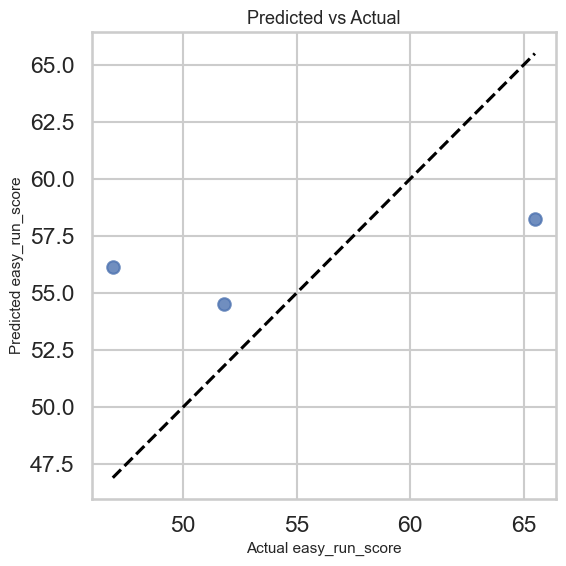

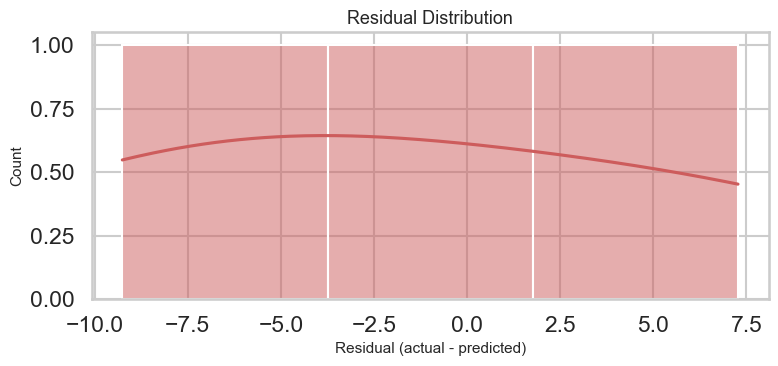

,feature,importance
93,decoupling_score,0.059938
88,steady_hr_std,0.040594
22,aerobic_drift_pct,0.032832
54,fatigue_resilience_score,0.032345
55,hr_z1_sec,0.029130
78,zone2_avg_power,0.027999
94,stability_score,0.025199
23,power_hr_decoupling_pct,0.024117
87,steady_hr_rise_bpm,0.023245
13,best_pace_min_per_km,0.022465


Saved:
- ..\reports\easy\easy_run_baseline_feature_importance.csv
- ..\reports\easy\easy_run_baseline_predictions.csv


In [35]:
if model_result:
    y_test = model_result["y_test"]
    y_pred = model_result["y_pred"]

    # Predicted vs actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.8)
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--", color="black")
    plt.xlabel("Actual easy_run_score")
    plt.ylabel("Predicted easy_run_score")
    plt.title("Predicted vs Actual")
    plt.tight_layout()
    plt.show()

    # Residuals
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 4))
    sns.histplot(residuals, kde=True, color="indianred")
    plt.title("Residual Distribution")
    plt.xlabel("Residual (actual - predicted)")
    plt.tight_layout()
    plt.show()

    # Feature importance export
    model = model_result["model"]
    fi = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(fi.head(20))

    fi_path = OUTPUT_DIR / "easy_run_baseline_feature_importance.csv"
    pred_path = OUTPUT_DIR / "easy_run_baseline_predictions.csv"

    fi.to_csv(fi_path, index=False)
    pd.DataFrame({
        "actual": y_test.values,
        "predicted": y_pred,
        "residual": residuals,
    }).to_csv(pred_path, index=False)

    print("Saved:")
    print("-", fi_path)
    print("-", pred_path)
else:
    print("No model artifact export because no model was trained.")

## Practical Conclusions Template

Use this after each weekly update.

- This week, EF trend looked: ...
- Decoupling trend looked: ...
- Best run execution pattern was: ...
- Main risk signal was: ...
- Next-run focus (single priority): ...